<a href="https://colab.research.google.com/github/humendra012006-collab/Monte-Carlo-Simulation-Google-Colab-Statistics-2/blob/main/Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Probability in Python**

##**Importing packages**
This imports required packages used in this simulation

In [ ]:
import math
import random
import matplotlib.pyplot as plt

print(pow(2,3))

8


- Factorial function to compute factorial of any number
- factorial (n) = n!

In [ ]:
def factorial(n):
  product = 1
  for i in range(1,n+1):
    product *= i
  return product

print(factorial(5))

120


- Combination function in order to compute

- Combination (n,r):
$$
C(n, r) = \frac{n!}{r!(n-r)!}
$$

In [ ]:
def Combination(n,r):
  return factorial(n)/(factorial(r)*factorial(n-r))

print(Combination(4,2))

6.0


- Binomial_PMF(n,p,success) : $F_x(k) = C(n,r)\times p^k\times (1-p)^{n-k}$
- success = Number of success in n trials

In [ ]:
def Binomial_PMF(n,p,success):
  return Combination(n,success)*pow(p,success)*pow(1-p,n-success)

print(Binomial_PMF(36,0.35,13))

0.13603547694779586


- It is Exceptation of a random variable
$$E(x) = \displaystyle\sum_{i=1}^\infty x_i\times P(X = x_i)$$

In [ ]:
def Exception_RV(m,p):
  theoretical = []
  sum = 0
  for term in range(m):
    theoretical.append(Binomial_PMF(m,p,term))
    sum += term*Binomial_PMF(m,p,term)
  return sum,theoretical

print(Exception_RV(36,0.35)[0])
print(Exception_RV(36,0.35)[1])

12.6
[1.8402670033873237e-07, 3.5672868065661966e-06, 3.361481798495069e-05, 0.00020513658154918627, 0.0009112798141896543, 0.0031404104365920387, 0.008736782881288109, 0.020161806649126403, 0.03935429567089095, 0.06592685428627885, 0.09584750353928233, 0.12198773177726842, 0.136845211929628, 0.13603547694779586, 0.12033907576151172, 0.09503701367832205, 0.06716558178227569, 0.04254833235076287, 0.024183453857484875, 0.012336498728919412, 0.005646320572082344, 0.002316439209059423, 0.0008504409683609771, 0.0002787398491617918, 8.129912267218926e-05, 2.1012696321427376e-05, 4.786916025887302e-06, 9.54655617698322e-07, 1.6522885690932495e-07, 2.4543278479899724e-08, 3.0836426808079138e-09, 3.2137219005938555e-10, 2.7038525605957917e-11, 1.7647522540019152e-12, 8.384569532588283e-14, 2.5798675484887025e-15]


#**Monte Carlo Simulation**

- Above we have computed Theoretical values and probability
- Now let's see if really those all matches with practical
- Below is ***simulate_once*** function which randomly picks number of success


In [ ]:
def simulate_once(m,p):
    success = 0
    for i in range(m):
        if random.random() < p:
            success += 1
    return success
print(simulate_once(36,0.35))

13


- ***simulation(m,p,N)*** : function simulate the the $X ~ Binomial(m,p)$ for N (large no. of times) and records number of success each time
-Even here also visible that the value at index 12 (i.e. No. of success equals 13 with simulation(36,0.35,100000)) remains highest among all for most of the time

In [ ]:
def simulation(m,p,N):
  frequency = [0]*m
  for i in range(N):
    result = simulate_once(m,p)
    try:
      frequency[result] += 1
    except:
      continue
  return frequency

print(simulation(36,0.35,100000))

[0, 0, 5, 26, 83, 304, 841, 1948, 3935, 6638, 9580, 12323, 13804, 13737, 11894, 9489, 6665, 4125, 2366, 1271, 595, 240, 94, 23, 14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


- Below function simpally takes frequency list form **simulation(m,p,N)** function and divides each frequency by **N** results in **Relative frequency**

In [ ]:
def expermental_results(frequency_list,N):
  experimental_prob = []
  for f in frequency_list:
    experimental_prob.append(f/N)
  return frequency_list,experimental_prob

print(expermental_results(simulation(36,0.35,10000),10000))

([0, 0, 0, 3, 12, 22, 83, 215, 406, 621, 998, 1171, 1392, 1351, 1191, 949, 663, 442, 249, 119, 70, 23, 14, 5, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 0.0003, 0.0012, 0.0022, 0.0083, 0.0215, 0.0406, 0.0621, 0.0998, 0.1171, 0.1392, 0.1351, 0.1191, 0.0949, 0.0663, 0.0442, 0.0249, 0.0119, 0.007, 0.0023, 0.0014, 0.0005, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])


- In order to plot the graph

In [ ]:
def graph(m,theoretical,experimental_prob):
    x = list(range(m))
    plt.figure(figsize=(8,5))
    plt.plot(x, theoretical,
             marker='o',
             linewidth=2,
             label='Theoretical Probability')

    plt.plot(x, experimental_prob,
             marker='x',
             linestyle='--',
             linewidth=2,
             label='Experimental Outcomes')
    plt.xlabel("Number of Successes")
    plt.ylabel("Probability")
    plt.title("Theoretical vs Monte Carlo Distribution")
    plt.grid(True)
    plt.legend()
    plt.show()

##Theoretical and Practicall outcones
- It shows that for very large no. of trials of $Binomial(36,0.35)$ we except that 12 is the number of success of most of the times

--Theoretical Results:
	Mode = 57
	With Highest Probability = 0.13169
--Practical Results:
	Most Frequency Value = 57
	With Relative Frequency = 0.13114




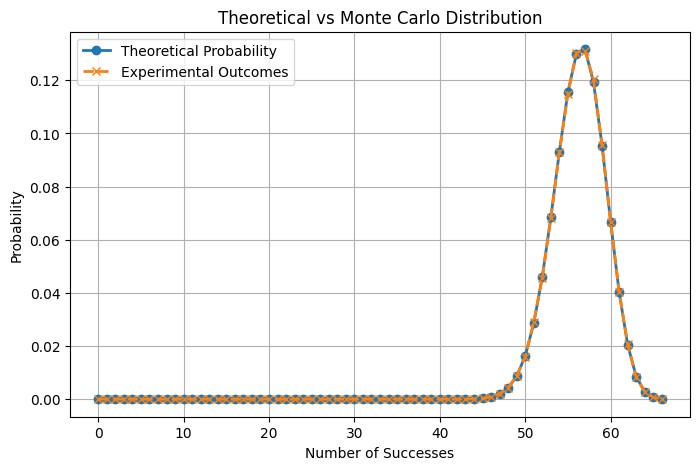

In [ ]:
def thero_bridge_practical(m,p,N):
  theoretical_results = Exception_RV(m,p)
  practical_results = expermental_results(simulation(m,p,N),N)
  #theory section
  Expected = theoretical_results[0]
  theoretical = theoretical_results[1]
  mode = theoretical.index(max(theoretical))
  #mode += 1 # as indexing starts with 0 in python list
  max_prob = max(theoretical)
  print("--Theoretical Results:")
  print(f"\tMode = {mode}")
  print(f"\tWith Highest Probability = {round(max_prob,len(str(N))-1)}")

  #practicall section
  frequency = practical_results[0]
  experimental_prob = practical_results[1]
  practical_mode = frequency.index(max(frequency))
  #practical_mode += 1
  practical_occurence = max(practical_results[1])
  print("--Practical Results:")
  print(f"\tMost Frequency Value = {practical_mode}")
  print(f"\tWith Relative Frequency = {round(practical_occurence,len(str(N))-1)}")
  print("\n")
  graph(m,theoretical,experimental_prob)

thero_bridge_practical(67,0.84,300000)

- Feel free to run with any sets of parameters (m,p,N)
- Note : take **N** large enoughf
###Analysis :
- For any valid set of parameters (m,p,N) Expectation of Random Variable meets with practical obeservations.

---
###Example :
1. with **thero_bridge_practical(36,0.35,200000)**
- Theoretical Results:
	- Mode = 12
	- With Highest Probability = 0.13685
- Practical Results:
	- Most Frequency Value = 12
	- With Relative Frequency = 0.13693

2. with **thero_bridge_practical(67,0.84,300000)**
- Theoretical Results:
	- Mode = 57
	- With Highest Probability = 0.13169
- Practical Results:
	- Most Frequency Value = 57
	- With Relative Frequency = 0.1315
